# PPE detection on construction imagery — YOLOv8

Dataset: `roboflow-100/construction-safety-gsnvb` (CC BY 4.0), forked to `caprijopi-hotmail-com`
and frozen as version 1. Classes: `helmet, no-helmet, no-vest, person, vest`.

Split (as generated in Roboflow): 1001 train / 121 valid / 84 test from 1206 source images. The
train split was augmented 3x (horizontal flip, brightness +/-15%) to 2983 images. This is the
dataset's native RF100 split, kept so results stay comparable with the published baseline.

**How to run:** Runtime → **Run all**. The dataset downloads from this repository's release with
**no API key and no account**, verified against a SHA256 checksum. Nothing is read from a local
drive.

**Expected runtime:** ~5 min setup and download, plus ~18 min training on a T4.

## 1. Environment

In [6]:
!nvidia-smi
!pip install -q ultralytics==8.4.155

import ultralytics, torch
print("ultralytics", ultralytics.__version__)
print("cuda", torch.cuda.is_available())

Sat Sep 19 11:15:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Dataset — keyless download

The dataset is a frozen export of Roboflow version 1, published as a release asset on this
repository. It downloads over plain HTTPS with **no API key and no account**, and the SHA256 check
proves it is byte-for-byte the file the published results were trained on.

Roboflow remains the annotation and versioning tool; section 2b keeps that path as a fallback, but
it does not run when the keyless dataset is already in place.

In [ ]:
import hashlib, zipfile, urllib.request, yaml
from pathlib import Path

DATA_URL = "https://github.com/caprijopi-alt/ppe-detection-yolov8/releases/download/v1.0/construction-safety-v1-yolov8.zip"
SHA256   = "9ae7044a16fc8d7364d52f23d023abde5e06da5d748ea126768358da636be7c4"
ROOT     = Path("/content/dataset")
ZIP_PATH = Path("/content/dataset.zip")


def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def find_data_yaml(root: Path) -> Path:
    hits = list(root.rglob("data.yaml"))
    if not hits:
        raise FileNotFoundError(f"No data.yaml under {root}")
    return hits[0]


already_ready = (ROOT / "data.yaml").exists() or any(ROOT.glob("*/data.yaml"))
if not already_ready:
    ROOT.mkdir(parents=True, exist_ok=True)
    if ZIP_PATH.exists():
        ZIP_PATH.unlink()
    print("downloading 190 MB ...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    digest = sha256_file(ZIP_PATH)
    if digest != SHA256:
        ZIP_PATH.unlink(missing_ok=True)
        raise AssertionError(f"Checksum mismatch: {digest}")
    print("checksum ok")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(ROOT)

cfg_path      = find_data_yaml(ROOT)
dataset_root  = cfg_path.parent
cfg           = yaml.safe_load(cfg_path.read_text())
cfg["path"]   = str(dataset_root)
cfg["train"]  = "train/images"
cfg["val"]    = "valid/images"
if (dataset_root / "test" / "images").is_dir():
    cfg["test"] = "test/images"
else:
    cfg.pop("test", None)
cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))

DATA_YAML = str(cfg_path)
print(cfg)

In [ ]:
!cat "{DATA_YAML}"

### 2b. Roboflow path (secondary, optional)

Skipped automatically when the keyless dataset is present, so **Run all** never stops for a
credential. Kept only so the Roboflow version this export came from stays visible and re-fetchable.
The version number is pinned; `"latest"` is never used.

In [ ]:
from pathlib import Path

if not list(Path("/content/dataset").rglob("data.yaml")):
    %pip install -q roboflow==1.5.0
    try:
        from google.colab import userdata
        api_key = userdata.get("ROBOFLOW_API_KEY")
    except Exception:
        from getpass import getpass
        api_key = getpass("Roboflow API key (any account works for public Universe datasets): ")

    from roboflow import Roboflow
    rf = Roboflow(api_key=api_key)
    rf.workspace("caprijopi-hotmail-com").project("construction-safety-gsnvb-oz6um").version(1).download(
        "yolov8", location="/content/dataset_roboflow"
    )
else:
    print("Keyless dataset already present; skipping Roboflow download.")

## 3. Dataset audit

Image counts per split and instances per class — evidence for the report.

In [9]:
from pathlib import Path
from collections import Counter
import yaml

root = dataset_root
names = cfg["names"]

for split in ["train", "valid", "test"]:
    d = root / split / "images"
    if d.exists():
        print(f"{split:6s} {len(list(d.glob('*')))} images")

counts = Counter()
for lbl in (root / "train" / "labels").glob("*.txt"):
    for line in lbl.read_text().splitlines():
        if line.strip():
            counts[names[int(line.split()[0])]] += 1

for k, v in counts.most_common():
    print(f"{k:12s} {v}")

train  2983 images
valid  121 images
test   84 images
person       7075
helmet       6330
vest         3221
no-vest      2222
no-helmet    291


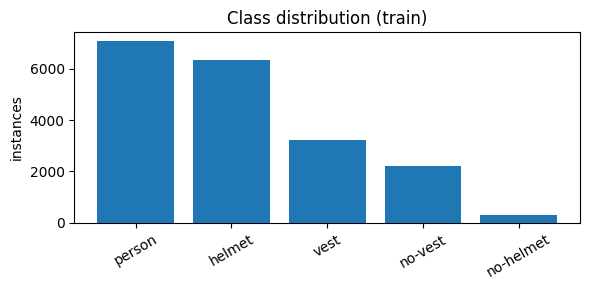

In [10]:
import matplotlib.pyplot as plt
import os

EVIDENCE = "/content/evidence"
os.makedirs(EVIDENCE, exist_ok=True)

ks = [k for k, _ in counts.most_common()]
vs = [counts[k] for k in ks]
plt.figure(figsize=(6, 3))
plt.bar(ks, vs)
plt.ylabel("instances")
plt.title("Class distribution (train)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{EVIDENCE}/class_distribution.png", dpi=150)
plt.show()

## 4. Train

`yolov8n` (nano) keeps a Colab T4 run to roughly 20 minutes at 50 epochs.
Swap to `yolov8s.pt` if you have time and want a second model to compare.

In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    seed=0,
    project="runs",
    name="ppe_yolov8n",
    exist_ok=True,
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/construction-safety-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_yolov8n, nbs=64, nms=None, opset=

In [ ]:
from pathlib import Path

RUN = str(sorted(Path("/content").rglob("ppe_yolov8n*/weights/best.pt"),
                 key=lambda p: p.stat().st_mtime)[-1].parent.parent)
print("run folder:", RUN)
!ls {RUN}

## 5. Validate

Overall and per-class metrics on the validation split.

In [14]:
best = YOLO(f"{RUN}/weights/best.pt")
metrics = best.val(data=DATA_YAML, split="val")

print(f"mAP@50     {metrics.box.map50:.3f}")
print(f"mAP@50-95  {metrics.box.map:.3f}")
print(f"precision  {metrics.box.mp:.3f}")
print(f"recall     {metrics.box.mr:.3f}")
print()
for i, c in enumerate(metrics.box.ap_class_index):
    print(f"{names[c]:12s} AP50 {metrics.box.ap50[i]:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: 'runs/ppe_yolov8n/weights/best.pt'

Training curves, confusion matrix and PR curve are written to the run folder — these are your results evidence.

In [ ]:
from IPython.display import Image, display

for f in ["results.png", "confusion_matrix_normalized.png", "BoxPR_curve.png"]:
    p = f"{RUN}/{f}"
    print(f)
    display(Image(p, width=700))

## 6. Predictions

Run on validation images and save annotated outputs for the slide pack.

In [ ]:
import random, shutil

val_imgs = sorted((root / "valid" / "images").glob("*"))
random.seed(0)
sample = random.sample(val_imgs, 6)

PRED = "/content/preds"
shutil.rmtree(PRED, ignore_errors=True)

best.predict(source=[str(p) for p in sample], conf=0.35, save=True,
             project="/content", name="preds", exist_ok=True)

from IPython.display import Image, display
for p in sorted(Path(PRED).glob("*.jpg")):
    display(Image(str(p), width=600))

## 7. Error analysis

Pull the lowest-confidence and missed detections to discuss in the report.
The published baseline has recall well below precision — check whether yours
shows the same pattern and on which classes.

In [ ]:
import numpy as np

per_class = {names[c]: (metrics.box.ap50[i], metrics.box.p[i], metrics.box.r[i])
             for i, c in enumerate(metrics.box.ap_class_index)}

print(f"{'class':12s} {'AP50':>6s} {'P':>6s} {'R':>6s}")
for k, (ap, p_, r_) in sorted(per_class.items(), key=lambda x: x[1][0]):
    print(f"{k:12s} {ap:6.3f} {p_:6.3f} {r_:6.3f}")

print()
print("Weakest class:", min(per_class, key=lambda k: per_class[k][0]))

## 8. Collect the evidence

Everything `results/` and `docs/pip_freeze.txt` need, gathered into one zip so the repo can be
updated in a single upload rather than file by file.

In [ ]:
# Collect everything the repo's results/ folder needs, in one archive.
import shutil, os
from pathlib import Path

os.makedirs(f"{EVIDENCE}/evidence", exist_ok=True)

for f in ["results.png", "confusion_matrix.png", "confusion_matrix_normalized.png",
          "BoxPR_curve.png", "BoxF1_curve.png", "args.yaml"]:
    p = Path(RUN) / f
    if p.exists():
        shutil.copy(p, EVIDENCE)

for p in sorted(Path(PRED).glob("*.jpg")):
    shutil.copy(p, f"{EVIDENCE}/evidence")

shutil.copy(f"{RUN}/weights/best.pt", EVIDENCE)

# environment snapshot, for docs/pip_freeze.txt
os.system(f"pip freeze > {EVIDENCE}/pip_freeze.txt")

shutil.make_archive("/content/results_pack", "zip", EVIDENCE)
print("contents of the pack:")
for p in sorted(Path(EVIDENCE).rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(EVIDENCE))

## 9. Download

`best.pt` goes to a GitHub Release (tag `v1.0`); the results pack unzips into `results/`.

In [ ]:
from google.colab import files
files.download("/content/results_pack.zip")
files.download(f"{RUN}/weights/best.pt")

## Attribution

Dataset: construction safety, Roboflow 100, licensed CC BY 4.0.
`https://universe.roboflow.com/roboflow-100/construction-safety-gsnvb`

Ciaglia et al., *Roboflow 100: A Rich, Multi-Domain Object Detection Benchmark*, 2022.